In [1]:
import os
from langchain.chat_models import init_chat_model


llm = init_chat_model(
    model="openai/gpt-oss-120b",
    model_provider="openai",
    api_key=os.getenv("NOVITA_API_KEY"),
    base_url="https://api.novita.ai/openai",
)
# llm = init_chat_model(model="ollama:qwen2.5:3b")

/home/vasim/Programming/ai-engineering/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
llm.invoke("hello")

AIMessage(content='Hi there! How’s your day going? :)', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 44, 'prompt_tokens': 55, 'total_tokens': 99, 'completion_tokens_details': None, 'prompt_tokens_details': None}, 'model_provider': 'openai', 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': '', 'id': 'c15f08fab5d9f93ac04482b8673420a4', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019bff12-9e54-7af2-82d7-b42e90c98586-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 55, 'output_tokens': 44, 'total_tokens': 99, 'input_token_details': {}, 'output_token_details': {}})

### Parallelization

In [6]:
from typing import TypedDict
from langgraph.graph import StateGraph, END, START
from IPython.display import Image, display

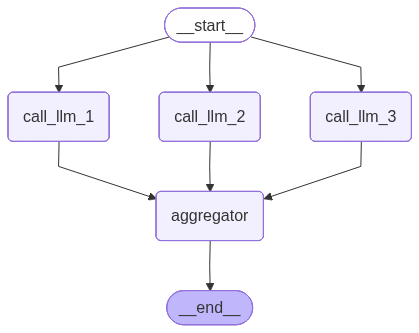

Here's a story, joke, and poem about cats!

STORY:
**The Moonlight Tailors**

In the heart of a bustling old town, where cobblestones sang under the tread of hurried feet and the scent of freshly baked bread curled out of every kitchen window, there lived a secret guild known only to the night‑watching cats.

At the center of this hidden society was an ancient, ivy‑clad workshop called **The Moonlight Tailors**. Its doors, worn smooth by generations of paws, opened only when the moon hung low and silver in the sky. Inside, bolts of midnight silk and sun‑spun yarn glimmered on towering spindles, and the air was scented with a mixture of lavender, old paper, and the faintest hint of fish oil.

The guild was led by **Sir Whiskerford**, an indigo‑gray tom with a scar shaped like a comet across his left ear. He wore a tiny, brass‑capped monocle that perched on the tip of his nose, and his tail always ended in a perfect curl, as if it were a question mark waiting for an answer. Whiskerford’s

In [7]:
# Graph state
class State(TypedDict):
    topic: str
    joke: str
    story: str
    poem: str
    combined_output: str


# Nodes
def call_llm_1(state: State):
    """First LLM call to generate initial joke"""

    msg = llm.invoke(f"Write a joke about {state['topic']}")
    return {"joke": msg.content}


def call_llm_2(state: State):
    """Second LLM call to generate story"""

    msg = llm.invoke(f"Write a story about {state['topic']}")
    return {"story": msg.content}


def call_llm_3(state: State):
    """Third LLM call to generate poem"""

    msg = llm.invoke(f"Write a poem about {state['topic']}")
    return {"poem": msg.content}


def aggregator(state: State):
    """Combine the joke, story and poem into a single output"""

    combined = f"Here's a story, joke, and poem about {state['topic']}!\n\n"
    combined += f"STORY:\n{state['story']}\n\n"
    combined += f"JOKE:\n{state['joke']}\n\n"
    combined += f"POEM:\n{state['poem']}"
    return {"combined_output": combined}


# Build workflow
parallel_builder = StateGraph(State)

# Add nodes
parallel_builder.add_node("call_llm_1", call_llm_1)
parallel_builder.add_node("call_llm_2", call_llm_2)
parallel_builder.add_node("call_llm_3", call_llm_3)
parallel_builder.add_node("aggregator", aggregator)

# Add edges to connect nodes
parallel_builder.add_edge(START, "call_llm_1")
parallel_builder.add_edge(START, "call_llm_2")
parallel_builder.add_edge(START, "call_llm_3")
parallel_builder.add_edge("call_llm_1", "aggregator")
parallel_builder.add_edge("call_llm_2", "aggregator")
parallel_builder.add_edge("call_llm_3", "aggregator")
parallel_builder.add_edge("aggregator", END)
parallel_workflow = parallel_builder.compile()

# Show workflow
display(Image(parallel_workflow.get_graph().draw_mermaid_png()))

# Invoke
state = parallel_workflow.invoke({"topic": "cats"})
print(state["combined_output"])